# Notebook 2 — Benchmark des modèles de détection d’anomalies PCB

## Plan :
**1. Introduction**
  - But du notebook
  - Modèles comparés
  - Critères de comparaison

**2. Chargement de la configuration et préparation**
  - Imports
  - Lecture de `config.yml`
  - Lecture de `data.yaml`
  - Initialisation des chemins, classes et paramètres globaux
  - Fixation du seed

**3. Définition du benchmark**
  - Modèles retenus
  - Paramètres d’entraînement
  - Métriques suivies

**4. Fonctions utilitaires du benchmark**
  - Chargement de la configuration
  - Initialisation de MLflow
  - Fonction de lancement d’un entraînement par modèle
  - Fonction de collecte / harmonisation des métriques
    
**5. Entraînement et suivi des expérimentations**
  - Boucle d'entraînement des modèles
  - Récupération et mise en forme des résultats
  - Ajustement des hyperparamètres de YOLOv8s

**6. Comparaison des résultats**
  - Comparaison visuelle des métriques
  - Analyse des écarts entre modèles
  - Comparaison des configurations testées pour YOLOv8s

**7. Sélection du modèle final**
  - Modèle retenu
  - Justification du choix
  - Analyse du modèle retenu

**8. Visualisation des prédictions sur test set**

# 1. Introduction
- **But du notebook :** comparer plusieurs modèles de détection d’objets sur le dataset **PCB Defect Dataset** afin d’identifier le modèle le plus pertinent pour détecter automatiquement des anomalies sur des cartes électroniques.
- **Modèles comparés :** `yolov8s`,`faster_rcnn_resnet50_fpn`.
- **Source de configuration :** le notebook s’appuie sur `config.yml` pour les paramètres généraux du projet et sur `data.yaml` pour la description du dataset.
- **Critère principal de comparaison :** `mAP50-95` comme critère principal, complété par `mAP50`, le temps d’entraînement et le temps d’inférence.
- **Ajustement complémentaire** : après la comparaison initiale, plusieurs configurations de yolov8s sont testées en faisant varier certains hyperparamètres (epochs, learning_rate, batch_size) afin de retenir la meilleure configuration finale.
- **Suivi des expérimentations :** les runs sont tracés avec **MLflow** ; les artefacts d’entraînement sont conservés dans `outputs/models/` et le meilleur modèle YOLO est copié sous un nom stable.

# 2. Chargement de la configuration et préparation

## 2.1 Imports

In [1]:
from ultralytics import YOLO

from pathlib import Path
from typing import Any
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import yaml
import mlflow
import shutil
import sys
from collections import defaultdict


/Users/agnes/anaconda3/envs/pcb-defect-detection_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2.2 Chargement de la configuration et des chemins du projet

In [2]:
# Configuration
def load_yaml_file(file_path: Path) -> dict[str, Any]:
    """Load a YAML file and return its content."""
    with open(file_path, "r", encoding="utf-8") as file:
        return yaml.safe_load(file)


def set_random_seed(seed: int) -> None:
    """Set random seed for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)


project_root: Path = Path("..")
sys.path.insert(0, str(project_root.resolve()))

from src.utils import resolve_device

config_path: Path = project_root / "config.yml"

config: dict[str, Any] = load_yaml_file(config_path)

dataset_root: Path = project_root / config["dataset"]["root_dir"]
dataset_yaml_path: Path = dataset_root / "data.yaml"
outputs_root: Path = project_root / "outputs"
metrics_dir = project_root / config["outputs"]["metrics_dir"]
metrics_dir.mkdir(parents=True, exist_ok=True)

data_config: dict[str, Any] = load_yaml_file(dataset_yaml_path)

random_seed: int = config["project"]["random_seed"]
set_random_seed(random_seed)

class_mapping: dict[int, str] = data_config["names"]
class_names: list[str] = [class_mapping[i] for i in sorted(class_mapping)]
num_classes: int = len(class_names)

print(f"Dataset root: {dataset_root}")
print(f"Dataset YAML: {dataset_yaml_path}")
print(f"Number of classes: {num_classes}")
print(f"Classes: {class_names}")

Dataset root: ../data/raw/pcb-defect-dataset
Dataset YAML: ../data/raw/pcb-defect-dataset/data.yaml
Number of classes: 6
Classes: ['mouse_bite', 'spur', 'missing_hole', 'short', 'open_circuit', 'spurious_copper']


## 2.3 Lecture de data.yaml et extraction des informations du dataset

In [3]:
config_summary: pd.DataFrame = pd.DataFrame(
    {
        "parameter": [
            "random_seed",
            "dataset_name",
            "dataset_root_dir",
            "selected_models",
            "image_size",
            "epochs",
            "device",
            "num_workers",
        ],
        "value": [
            config["project"]["random_seed"],
            config["dataset"]["name"],
            config["dataset"]["root_dir"],
            ", ".join(config["benchmark"]["selected_models"]),
            config["training"]["image_size"],
            config["training"]["epochs"],
            config["training"]["device"],
            config["training"]["num_workers"],
        ],
    }
)

config_summary

,parameter,value
0,random_seed,42
1,dataset_name,pcb_defect_dataset
2,dataset_root_dir,data/raw/pcb-defect-dataset
3,selected_models,"yolov8s, faster_rcnn_resnet50_fpn"
4,image_size,640
5,epochs,10
6,device,auto
7,num_workers,4


In [4]:
# Dataset summary
data_summary: pd.DataFrame = pd.DataFrame(
    {
        "parameter": ["dataset_yaml_path", "num_classes", "class_names"],
        "value": [
            str(dataset_yaml_path),
            num_classes,
            ", ".join(class_names),
        ],
    }
)

data_summary

,parameter,value
0,dataset_yaml_path,../data/raw/pcb-defect-dataset/data.yaml
1,num_classes,6
2,class_names,"mouse_bite, spur, missing_hole, short, open_ci..."


## 2.4 Initialisation et vérification des chemins du projet

In [5]:
train_images_dir: Path = dataset_root / "train" / "images"
train_labels_dir: Path = dataset_root / "train" / "labels"
val_images_dir: Path = dataset_root / "val" / "images"
val_labels_dir: Path = dataset_root / "val" / "labels"
test_images_dir: Path = dataset_root / "test" / "images"
test_labels_dir: Path = dataset_root / "test" / "labels"

paths_summary: pd.DataFrame = pd.DataFrame(
    {
        "path_name": [
            "dataset_root",
            "dataset_yaml_path",
            "train_images_dir",
            "train_labels_dir",
            "val_images_dir",
            "val_labels_dir",
            "test_images_dir",
            "test_labels_dir",
        ],
        "path_value": [
            str(dataset_root),
            str(dataset_yaml_path),
            str(train_images_dir),
            str(train_labels_dir),
            str(val_images_dir),
            str(val_labels_dir),
            str(test_images_dir),
            str(test_labels_dir),
        ],
        "exists": [
            dataset_root.exists(),
            dataset_yaml_path.exists(),
            train_images_dir.exists(),
            train_labels_dir.exists(),
            val_images_dir.exists(),
            val_labels_dir.exists(),
            test_images_dir.exists(),
            test_labels_dir.exists(),
        ],
    }
)

paths_summary

,path_name,path_value,exists
0,dataset_root,../data/raw/pcb-defect-dataset,True
1,dataset_yaml_path,../data/raw/pcb-defect-dataset/data.yaml,True
2,train_images_dir,../data/raw/pcb-defect-dataset/train/images,True
3,train_labels_dir,../data/raw/pcb-defect-dataset/train/labels,True
4,val_images_dir,../data/raw/pcb-defect-dataset/val/images,True
5,val_labels_dir,../data/raw/pcb-defect-dataset/val/labels,True
6,test_images_dir,../data/raw/pcb-defect-dataset/test/images,True
7,test_labels_dir,../data/raw/pcb-defect-dataset/test/labels,True


# 3. Définition du benchmark

## 3.1 Modèles retenus

In [6]:
selected_models: list[str] = config["benchmark"]["selected_models"]
baseline_model: str = config["benchmark"]["baseline_model"]
primary_model: str = config["benchmark"]["primary_model"]

models_summary: pd.DataFrame = pd.DataFrame(
    {
        "parameter": ["selected_models", "baseline_model", "primary_model"],
        "value": [
            ", ".join(selected_models),
            baseline_model,
            primary_model,
        ],
    }
)

models_summary

,parameter,value
0,selected_models,"yolov8s, faster_rcnn_resnet50_fpn"
1,baseline_model,faster_rcnn_resnet50_fpn
2,primary_model,yolov8s


## 3.2 Paramètres d’entraînement

In [7]:
training_config: dict[str, Any] = config["training"]

training_params_summary: pd.DataFrame = pd.DataFrame(
    {
        "parameter": [
            "image_size",
            "yolov8s_epochs",
            "faster_rcnn_epochs",
            "device",
            "num_workers",
            "augmentation_enabled",
            "horizontal_flip",
            "vertical_flip",
            "rotation_degrees",
            "brightness_contrast",
            "primary_selection_metric",
            "secondary_selection_metric",
            "tertiary_selection_metric",
            "reported_additional_metrics",
            "faster_rcnn_train_subset",
            "faster_rcnn_val_subset",
        ],
        "value": [
            training_config["image_size"],
            config["training"]["epochs"],
            config["models"]["faster_rcnn_resnet50_fpn"]["epochs"],
            training_config["device"],
            training_config["num_workers"],
            training_config["augmentation"]["enabled"],
            training_config["augmentation"]["horizontal_flip"],
            training_config["augmentation"]["vertical_flip"],
            training_config["augmentation"]["rotation_degrees"],
            training_config["augmentation"]["brightness_contrast"],
            "mAP50-95",
            "inference_time",
            "mAP50",
            "training_time, inference_time",
            config["models"]["faster_rcnn_resnet50_fpn"]["train_subset_size"],
            config["models"]["faster_rcnn_resnet50_fpn"]["val_subset_size"],
        ],
    }
)

training_params_summary

,parameter,value
0,image_size,640
1,yolov8s_epochs,10
2,faster_rcnn_epochs,1
3,device,auto
4,num_workers,4
5,augmentation_enabled,True
6,horizontal_flip,0.5
7,vertical_flip,0.0
8,rotation_degrees,5
9,brightness_contrast,0.2


### Configuration d’entraînement utilisée

- **YOLOv8s baseline** : entraînement sur le split `train` défini dans `data.yaml`, avec les paramètres de `config.yml`.
- **Faster R-CNN** : entraînement limité à **3 000 images train** et validation sur **400 images val** pour garder un temps d’exécution raisonnable en local (configuration allégée définie dans `config.yml`)
- **Faster R-CNN** est forcé en `cpu`, avec `epochs=1`, `batch_size=2` et `num_workers=0`.
- Les deux modèles sont comparés avec les mêmes métriques finales : `mAP50-95`, `mAP50`, `training_time`, `inference_time`.

In [8]:
model_training_rows: list[dict[str, Any]] = []

for model_name in config["benchmark"]["selected_models"]:
    model_cfg: dict[str, Any] = config["models"][model_name]

    model_training_rows.append(
        {
            "model_name": model_name,
            "pretrained": model_cfg["pretrained"],
            "batch_size": model_cfg["batch_size"],
            "optimizer": model_cfg["optimizer"],
            "learning_rate": model_cfg["learning_rate"],
            "weight_decay": model_cfg["weight_decay"],
            "scheduler_enabled": model_cfg["scheduler"]["enabled"],
            "scheduler_name": model_cfg["scheduler"]["name"],
            "early_stopping_enabled": model_cfg["early_stopping"]["enabled"],
        }
    )

model_training_summary: pd.DataFrame = pd.DataFrame(model_training_rows)
model_training_summary

,model_name,pretrained,batch_size,optimizer,learning_rate,weight_decay,scheduler_enabled,scheduler_name,early_stopping_enabled
0,yolov8s,True,16,adamw,0.001,0.0005,True,reduce_on_plateau,False
1,faster_rcnn_resnet50_fpn,True,2,sgd,0.005,0.0005,True,step_lr,False


## 3.3 Métriques suivies

### Rappel des métriques de détection

- **IoU (Intersection over Union)** : mesure le chevauchement entre une bounding box prédite et une bounding box réelle.  
  Plus l’IoU est élevé, plus la localisation est précise.

- **AP (Average Precision)** : score calculé pour une classe donnée, qui résume la courbe precision-recall pour un seuil d’IoU fixé.

- **mAP (mean Average Precision)** : moyenne des AP sur l’ensemble des classes.

- **mAP50** : mAP calculée avec un seuil d’IoU de 0.50.

- **mAP50-95** : moyenne des mAP calculées sur plusieurs seuils d’IoU, de 0.50 à 0.95.  
  Cette métrique est plus exigeante et constitue le critère principal retenu pour comparer les modèles dans ce benchmark.

- **Temps d’inférence** : temps moyen nécessaire pour traiter une image en phase de validation.
Cette métrique permet d’évaluer le compromis entre performance de détection et rapidité d’exécution.

**--> Métriques retenues pour comparaison** : 
- **Critère principal de sélection :** `mAP50-95`
- **Critère secondaire :** temps d’inférence
- **Critère tertiaire :** `mAP50`
- **Métriques affichées dans le tableau comparatif :** `mAP50-95`, `mAP50`, `training_time`, `inference_time`
- **Analyse complémentaire :** AP par classe

# 4. Fonctions utilitaires du benchmark

## 4.1 Initialisation de MLflow

In [9]:
mlflow.set_tracking_uri((project_root / "mlruns").resolve().as_uri())
print(mlflow.get_tracking_uri())

file:///Users/agnes/Library/CloudStorage/OneDrive-Personnel/Freelancing%20Data/Projets_perso/Detection_anomalies_cartes_electroniques/pcb-defect-detection/mlruns


## 4.2 Import des fonctions utilitaires du benchmark

In [10]:
from src.modeling import (
    format_benchmark_result,
    is_better_result,
    log_run_to_mlflow,
    train_model,
)

## 4.3 Rôle des fonctions utilitaires

### --> Les fonctions utilitaires du benchmark sont définies dans `src/modeling.py` puis importées dans ce notebook pour piloter les entraînements, harmoniser les résultats, suivre les runs avec MLflow et sauvegarder le meilleur modèle.

# 5. Entraînement et suivi des expérimentations

## 5.1 Boucle d’entraînement des modèles

In [11]:
# Use a dedicated MLflow experiment for the final clean runs.
mlflow.set_experiment("pcb_defect_benchmark_final")

/Users/agnes/anaconda3/envs/pcb-defect-detection_env/lib/python3.11/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


<Experiment: artifact_location=('file:///Users/agnes/Library/CloudStorage/OneDrive-Personnel/Freelancing '
 'Data/Projets_perso/Detection_anomalies_cartes_electroniques/pcb-defect-detection/notebooks/../mlruns/508302271126779451'), creation_time=1785321340958, experiment_id='508302271126779451', last_update_time=1785321340958, lifecycle_stage='active', name='pcb_defect_benchmark_final', tags={}, workspace='default'>

In [12]:
benchmark_results: list[dict[str, Any]] = []

selected_models: list[str] = config["benchmark"]["selected_models"]

outputs_dir: Path = project_root / config["outputs"]["models_dir"]

# Remove previous training outputs to keep only the final benchmark artifacts.
if outputs_dir.exists():
    shutil.rmtree(outputs_dir)
outputs_dir.mkdir(parents=True, exist_ok=True)


for model_name in selected_models:
    print(f"\n=== Training {model_name} ===")

    model_config: dict[str, Any] = config["models"][model_name].copy()
    training_config: dict[str, Any] = config["training"].copy()

    training_config["device"] = resolve_device(training_config["device"])

    if model_name == "faster_rcnn_resnet50_fpn":
        training_config["device"] = "cpu" if model_config["force_cpu"] else training_config["device"]
        training_config["num_workers"] = model_config["num_workers"]
        training_config["epochs"] = model_config["epochs"]

    raw_metrics: dict[str, Any] = train_model(
        model_name=model_name,
        data_yaml_path=dataset_yaml_path,
        training_config=training_config,
        model_config=model_config,
        outputs_dir=outputs_dir,
    )

    benchmark_result: dict[str, Any] = format_benchmark_result(
        model_name=model_name,
        raw_metrics=raw_metrics,
    )
    benchmark_results.append(benchmark_result)

    log_run_to_mlflow(
        model_name=model_name,
        epochs=training_config["epochs"],
        batch_size=model_config["batch_size"],
        image_size=training_config["image_size"],
        metrics=benchmark_result,
        artifact_dir=outputs_dir / model_name,
    )


benchmark_results_df: pd.DataFrame = pd.DataFrame(benchmark_results)[
    ["model_name", "map50_95", "map50", "training_time", "inference_time"]
]



=== Training yolov8s ===
Ultralytics 8.4.26 🚀 Python-3.11.15 torch-2.11.0 MPS (Apple M2 Max)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/raw/pcb-defect-dataset/data.yaml, degrees=5, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s, nbs=64, nms=False, opset=None, optimize=False, optimizer=adamw, overlap_mask=True, pati

## 5.2 Récupération et mise en forme des résultats

In [13]:
tracking_uri: str = mlflow.get_tracking_uri()
print(f"MLflow tracking URI: {tracking_uri}")

MLflow tracking URI: file:///Users/agnes/Library/CloudStorage/OneDrive-Personnel/Freelancing%20Data/Projets_perso/Detection_anomalies_cartes_electroniques/pcb-defect-detection/mlruns


In [14]:
benchmark_results_df

,model_name,map50_95,map50,training_time,inference_time
0,yolov8s,0.541107,0.985356,3908.030233,0.00518
1,faster_rcnn_resnet50_fpn,0.329017,0.765709,3737.452709,0.48874


In [15]:
# Sauvegarde des résultats
benchmark_results_df.to_csv(metrics_dir / "benchmark_results.csv", index=False)

## 5.3 Ajustement des hyperparamètres de YOLOv8s

In [16]:
best_models_dir: Path = project_root / "outputs" / "models" / "best"
best_models_dir.mkdir(parents=True, exist_ok=True)

yolo_tuning_results: list[dict[str, Any]] = [
    benchmark_results_df.loc[benchmark_results_df["model_name"] == "yolov8s"].iloc[0].to_dict()
]

yolo_experiments: list[dict[str, Any]] = [
    {
        "run_name": "yolov8s_epochs_20",
        "epochs": 20,
        "batch_size": config["models"]["yolov8s"]["batch_size"],
        "learning_rate": config["models"]["yolov8s"]["learning_rate"],
    },
    {
        "run_name": "yolov8s_lr_0.0005",
        "epochs": config["training"]["epochs"],
        "batch_size": config["models"]["yolov8s"]["batch_size"],
        "learning_rate": 0.0005,
    },
    {
        "run_name": "yolov8s_batch_8",
        "epochs": config["training"]["epochs"],
        "batch_size": 8,
        "learning_rate": config["models"]["yolov8s"]["learning_rate"],
    },
]

# Keep track of the best YOLO configuration found during tuning.
best_yolo_result: dict[str, Any] = yolo_tuning_results[0]
best_yolo_model_path: Path = outputs_dir / "yolov8s" / "weights" / "best.pt"

for experiment in yolo_experiments:
    print(f"\n=== Tuning run: {experiment['run_name']} ===")

    tuned_training_config: dict[str, Any] = config["training"].copy()
    tuned_model_config: dict[str, Any] = config["models"]["yolov8s"].copy()

    tuned_training_config["device"] = resolve_device(tuned_training_config["device"])
    
    tuned_training_config["epochs"] = experiment["epochs"]
    tuned_model_config["batch_size"] = experiment["batch_size"]
    tuned_model_config["learning_rate"] = experiment["learning_rate"]

    raw_metrics: dict[str, Any] = train_model(
        model_name="yolov8s",
        data_yaml_path=dataset_yaml_path,
        training_config=tuned_training_config,
        model_config=tuned_model_config,
        outputs_dir=outputs_dir,
        run_name=experiment["run_name"],
    )

    benchmark_result: dict[str, Any] = format_benchmark_result(
        model_name=experiment["run_name"],
        raw_metrics=raw_metrics,
    )
    yolo_tuning_results.append(benchmark_result)

    log_run_to_mlflow(
        model_name=experiment["run_name"],
        epochs=tuned_training_config["epochs"],
        batch_size=tuned_model_config["batch_size"],
        image_size=tuned_training_config["image_size"],
        metrics=benchmark_result,
        artifact_dir=outputs_dir / experiment["run_name"],
    )
    # Update the best YOLO configuration if the current run is better.
    if is_better_result(benchmark_result, best_yolo_result):
        best_yolo_result = benchmark_result
        best_yolo_model_path = raw_metrics["model_path"]

# Save the final YOLO model under a stable name.

shutil.copy2(
    best_yolo_model_path,
    best_models_dir / "best_yolo_tuned.pt",
)


yolo_tuning_results_df: pd.DataFrame = pd.DataFrame(yolo_tuning_results)[
    ["model_name", "map50_95", "map50", "training_time", "inference_time"]
]


=== Tuning run: yolov8s_epochs_20 ===
Ultralytics 8.4.26 🚀 Python-3.11.15 torch-2.11.0 MPS (Apple M2 Max)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/raw/pcb-defect-dataset/data.yaml, degrees=5, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_epochs_20, nbs=64, nms=False, opset=None, optimize=False, optimizer=adamw, 

In [17]:
yolo_tuning_results_df

,model_name,map50_95,map50,training_time,inference_time
0,yolov8s,0.541107,0.985356,3908.030233,0.005180
1,yolov8s_epochs_20,0.575858,0.987466,7563.518805,0.003775
2,yolov8s_lr_0.0005,0.551073,0.984571,3668.516471,0.003713
3,yolov8s_batch_8,0.530857,0.979591,3912.984771,0.008323


In [18]:
# Sauvegarde des résultats
yolo_tuning_results_df.to_csv(metrics_dir / "yolo_tuning_results.csv", index=False)

# 6. Comparaison des résultats

## 6.1 Comparaison visuelle des métriques

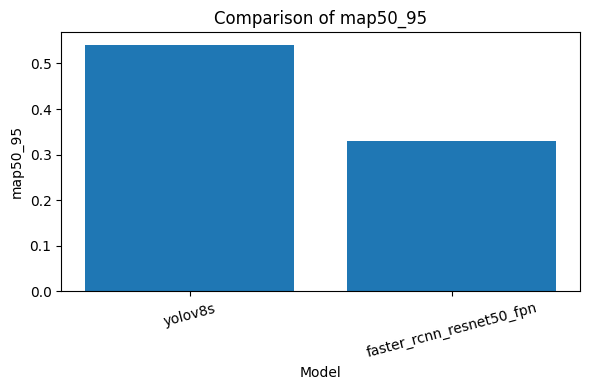

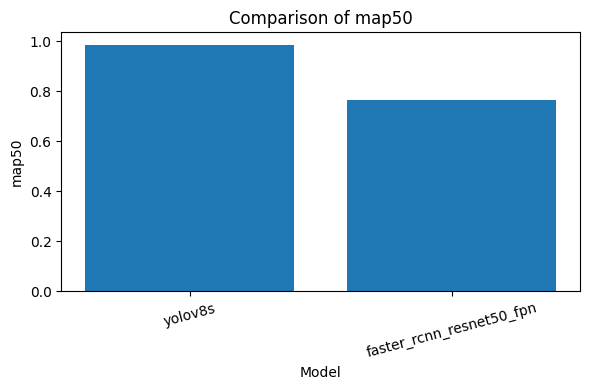

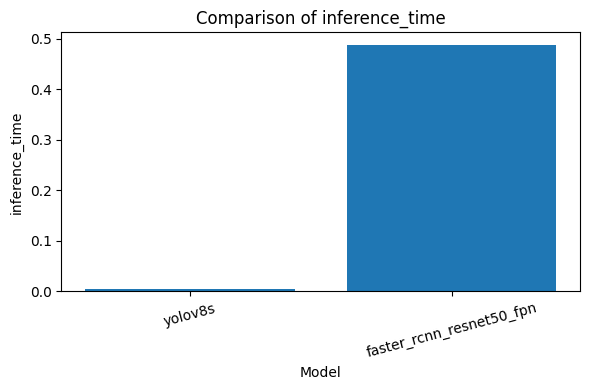

In [19]:
metrics_to_plot: list[str] = ["map50_95", "map50", "inference_time"]

for metric in metrics_to_plot:
    plt.figure(figsize=(6, 4))
    plt.bar(benchmark_results_df["model_name"], benchmark_results_df[metric])
    plt.title(f"Comparison of {metric}")
    plt.xlabel("Model")
    plt.ylabel(metric)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

## 6.2 Analyse des écarts entre modèles Yolo et FasterRCNN

* YOLOv8s surpasse Faster R-CNN sur ce benchmark, avec de meilleurs scores en mAP50-95 et mAP50.
* Le temps d’entraînement est ici du même ordre de grandeur, ce qui rend la comparaison plus équilibrée.
* L’avantage de YOLOv8s est particulièrement marqué sur le temps d’inférence, très inférieur à celui de Faster R-CNN.
* Faster R-CNN reste une baseline pertinente pour comparer une approche two-stage plus classique, mais il apparaît moins adapté ici à un usage opérationnel.

## 6.3 Comparaison des configurations testées pour YOLOv8s

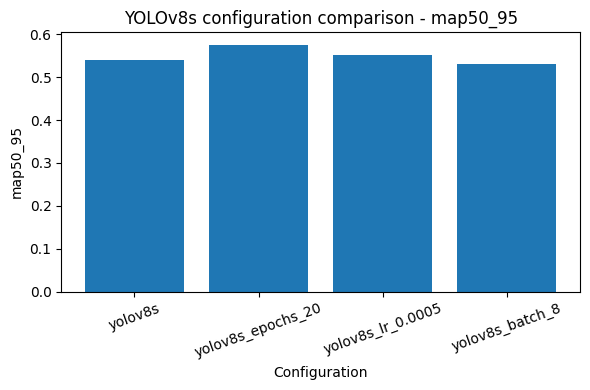

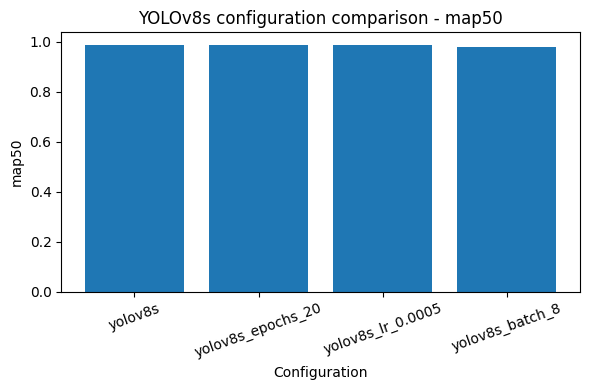

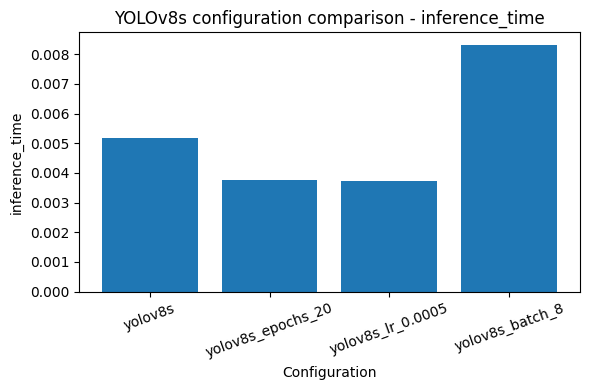

In [20]:
metrics_to_plot: list[str] = ["map50_95", "map50", "inference_time"]

for metric in metrics_to_plot:
    plt.figure(figsize=(6, 4))
    plt.bar(yolo_tuning_results_df["model_name"], yolo_tuning_results_df[metric])
    plt.title(f"YOLOv8s configuration comparison - {metric}")
    plt.xlabel("Configuration")
    plt.ylabel(metric)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

* L’augmentation à 20 époques donne le meilleur résultat global, avec la meilleure valeur de mAP50-95.
* La réduction du learning rate à 0.0005 améliore légèrement la baseline, mais reste en retrait par rapport à la configuration à 20 époques.
* La diminution du batch size à 8 dégrade les performances, malgré un temps d’entraînement proche de la baseline.
* La configuration yolov8s_epochs_20 est donc retenue pour la suite du projet.

# 7 Sélection du modèle final

## 7.1 Modèle retenu

Le modèle retenu pour la suite du projet est yolov8s_epochs_20.

## 7.2 Justification du choix

- `yolov8s_epochs_20` obtient le meilleur `mAP50-95`, critère principal du benchmark.
- Il conserve un très bon `mAP50` et un temps d’inférence faible.
- YOLOv8s est plus adapté que Faster R-CNN pour une détection exploitable en application, notamment grâce à sa rapidité d’inférence.
- Cette configuration est donc retenue comme meilleur compromis entre performance et efficacité.

## 7.3. Analyse du modèle retenu

### 7.3.1. Training dynamics

#### Dynamique d’entraînement

Deux vues complémentaires sont utilisées pour analyser l’entraînement :

- **mAP de validation (mAP50-95, mAP50)** : mesure la performance du modèle au fil des époques et sert à sélectionner le meilleur modèle.
- **Loss totale (train et validation)** : somme des pertes de localisation, classification et distribution, donnant une vision globale de l’optimisation.

Cette combinaison permet de vérifier à la fois :
- la **performance** (via la mAP)
- la **convergence et la généralisation** (via l’évolution des losses)

In [21]:
print("best_yolo_result =", best_yolo_result)
print("best_yolo_tuned exists =", (best_models_dir / "best_yolo_tuned.pt").exists())

best_yolo_result = {'model_name': 'yolov8s_epochs_20', 'map50_95': 0.575858177670571, 'map50': 0.9874655761896074, 'precision': 0.9697376387544744, 'recall': 0.9855370843382038, 'training_time': 7563.518804791, 'inference_time': 0.0037745448752388527}
best_yolo_tuned exists = True


In [22]:
best_run_name = best_yolo_result["model_name"]
best_run_results_path = outputs_dir / best_run_name / "results.csv"

results_df = pd.read_csv(best_run_results_path)
results_df.columns = results_df.columns.str.strip()  # utile avec les CSV Ultralytics

In [23]:
# Total loss = box + classification + distribution focal loss
results_df["train/total_loss"] = (
    results_df["train/box_loss"]
    + results_df["train/cls_loss"]
    + results_df["train/dfl_loss"]
)

results_df["val/total_loss"] = (
    results_df["val/box_loss"]
    + results_df["val/cls_loss"]
    + results_df["val/dfl_loss"]
)

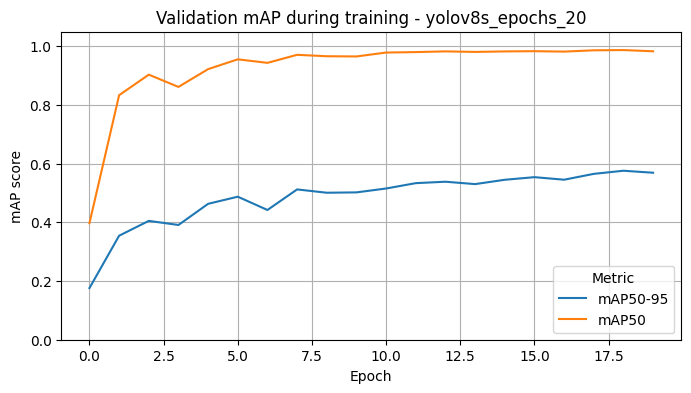

In [24]:
# Plot validation mAP
metrics_to_plot = results_df[
    ["metrics/mAP50-95(B)", "metrics/mAP50(B)"]
].rename(
    columns={
        "metrics/mAP50-95(B)": "mAP50-95",
        "metrics/mAP50(B)": "mAP50",
    }
)

metrics_to_plot.plot(figsize=(8, 4))
plt.title(f"Validation mAP during training - {best_run_name}")
plt.xlabel("Epoch")
plt.ylabel("mAP score")
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend(title="Metric")
plt.show()

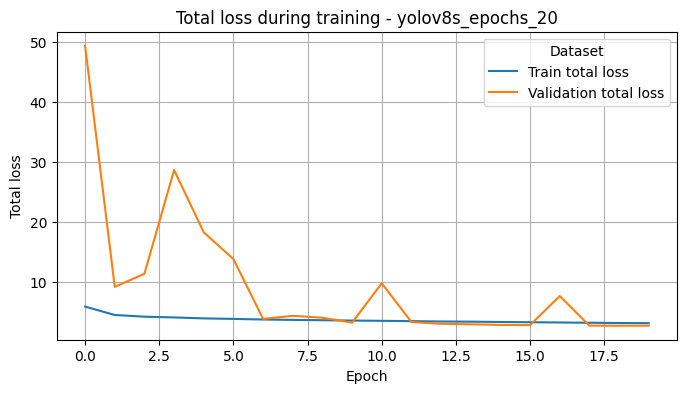

In [25]:
# Plot total training and validation loss
losses_to_plot = results_df[
    ["train/total_loss", "val/total_loss"]
].rename(
    columns={
        "train/total_loss": "Train total loss",
        "val/total_loss": "Validation total loss",
    }
)

losses_to_plot.plot(figsize=(8, 4))
plt.title(f"Total loss during training - {best_run_name}")
plt.xlabel("Epoch")
plt.ylabel("Total loss")
plt.grid(True)
plt.legend(title="Dataset")
plt.show()

### Interprétation

- Si la loss totale diminue sur train et validation → le modèle converge correctement.
- Si la loss train diminue mais la loss validation augmente → surapprentissage (overfitting).
- Si les deux stagnent ou oscillent fortement → optimisation instable ou insuffisante.

### 7.3.2. Confusion matrix on validation set

In [26]:
best_model = YOLO(str(best_models_dir / "best_yolo_tuned.pt"))

validation_dir = project_root / config["outputs"]["predictions_dir"]

confusion_results = best_model.val(
    data=str(dataset_yaml_path),
    split="val",
    imgsz=config["inference"]["image_size"],
    conf=config["inference"]["thresholds"]["confidence"],
    iou=config["inference"]["thresholds"]["iou"],
    device=resolve_device(config["inference"]["device"]),
    plots=True,
    project=str(validation_dir.resolve()),
    name="validation",
    exist_ok=True,
    verbose=False,
)

Ultralytics 8.4.26 🚀 Python-3.11.15 torch-2.11.0 MPS (Apple M2 Max)
Model summary (fused): 73 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 429.7±83.9 MB/s, size: 98.0 KB)
val: Scanning /Users/agnes/Library/CloudStorage/OneDrive-Personnel/Freelancing Data/Projets_perso/Detection_anomalies_cartes_electroniques/pcb-defect-detection/data/raw/pcb-defect-dataset/val/labels.cache... 802 images, 264 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1066/1066 894.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 67/67 4.0it/s 16.6s0.1s
                   all       1066       1595      0.975      0.981      0.984      0.597
Speed: 0.1ms preprocess, 3.8ms inference, 0.0ms loss, 3.9ms postprocess per image
Results saved to /Users/agnes/Library/CloudStorage/OneDrive-Personnel/Freelancing Data/Projets_perso/Detection_anomalies_cartes_electroniques/pcb-defect-detection/outputs/pr

Matrice de confusion avec le best model YOLO ci-dessous.
Nombre d'images utilisées pour la matrice : 1066


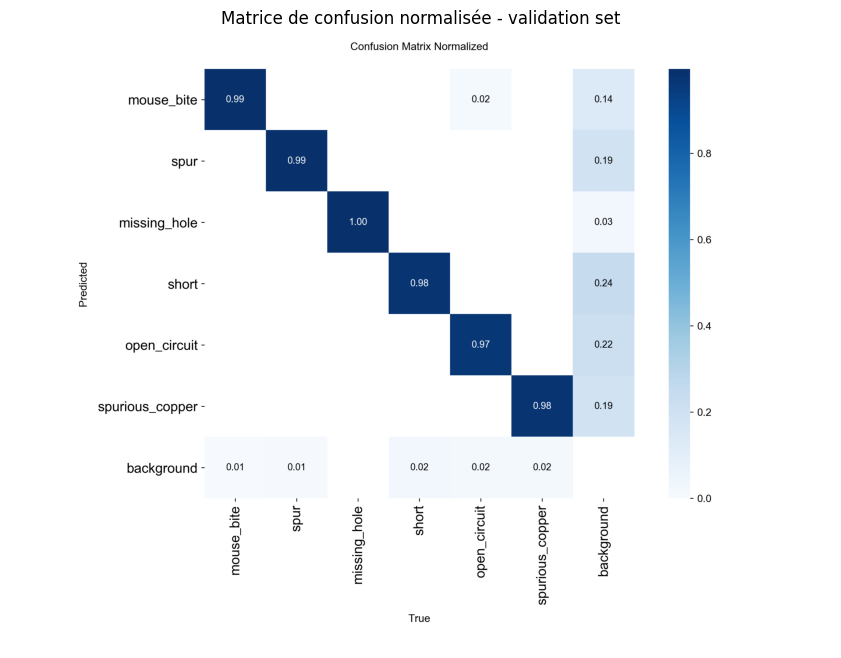

In [27]:
val_images_dir = dataset_root / "val" / "images"
num_val_images = len(list(val_images_dir.glob("*.jpg")))

print("Matrice de confusion avec le best model YOLO ci-dessous.")
print(f"Nombre d'images utilisées pour la matrice : {num_val_images}")

confusion_matrix_path = Path(confusion_results.save_dir) / "confusion_matrix_normalized.png"

img = plt.imread(confusion_matrix_path)

plt.figure(figsize=(11, 8))
plt.imshow(img)
plt.axis("off")
plt.title("Matrice de confusion normalisée - validation set")
plt.show()

### 7.3.3. Per-class performance

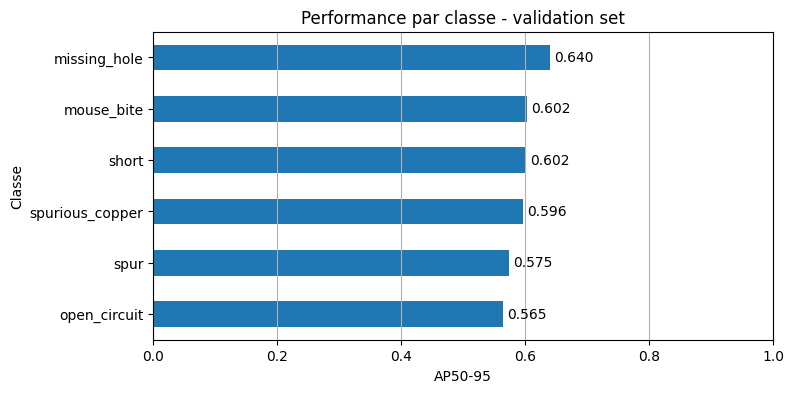

In [28]:
confusion_results.box.maps

per_class_df = pd.DataFrame(
    {
        "class_name": class_names,
        "ap50_95": confusion_results.box.maps,
    }
).sort_values("ap50_95")

ax = per_class_df.plot(
    x="class_name",
    y="ap50_95",
    kind="barh",
    figsize=(8, 4),
    legend=False,
)

plt.title("Performance par classe - validation set")
plt.xlabel("AP50-95")
plt.ylabel("Classe")
plt.xlim(0, 1)
plt.grid(axis="x")

# Ajout des valeurs sur les barres
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.show()

# Sauvegarde
per_class_metrics_path = metrics_dir / "per_class_metrics.csv"
per_class_df.to_csv(per_class_metrics_path, index=False)

AP (Average Precision) = mesure de performance pour une classe, qui combine précision et rappel sur différents seuils (ici résumé en AP50-95).

👉 Les performances par classe sont homogènes, avec un AP50-95 compris entre 0,565 et 0,640 selon les défauts. Tous les types de défaut sont détectés de manière homogène.

# 8. Visualisation des prédictions sur test set avec modèle retenu

### Étapes :

- Charge le modèle final YOLO sauvegardé dans `best_yolo_tuned.pt`.

- Définit les dossiers d’images et de labels du **test set**.

- Lit les fichiers labels `.txt` pour récupérer les **classes réelles (Ground Truth)** des images.

- Sélectionne jusqu’à **2 images par catégorie**, sans utiliser le nom du fichier pour déterminer la classe.

- Pour chaque image sélectionnée :
  - copie l’image originale dans `app/sample_images/originals/` ;
  - lance l’inférence avec le modèle retenu ;
  - sauvegarde l’image annotée dans `app/sample_images/predictions/`.

- Affiche les prédictions par catégorie réelle :
  - 1 ligne par classe ;
  - 2 images maximum ;
  - boxes + classes + scores via l’image annotée sauvegardée ;
  - nom du fichier affiché pour contrôle visuel.

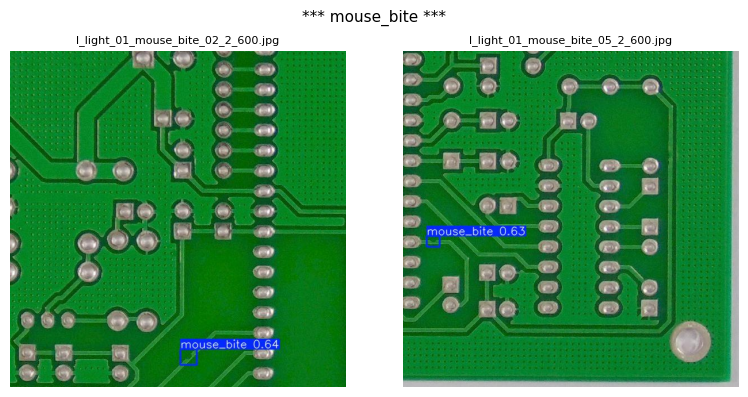

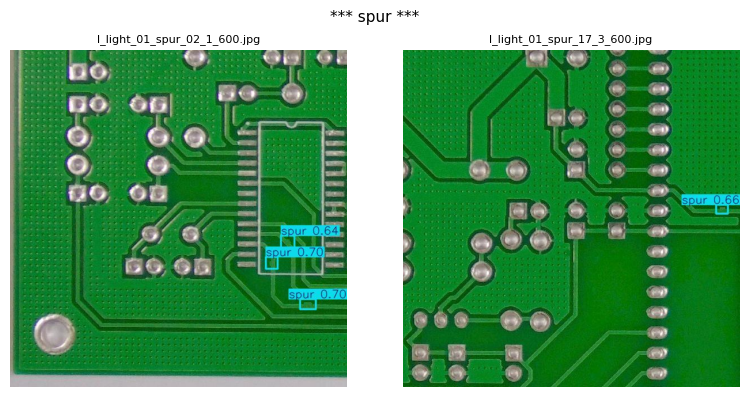

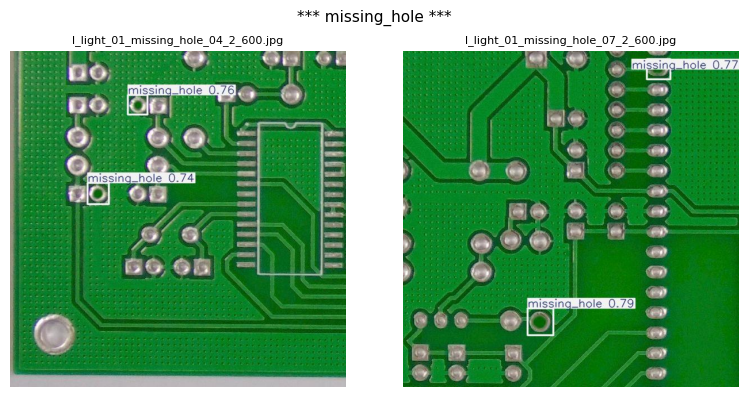

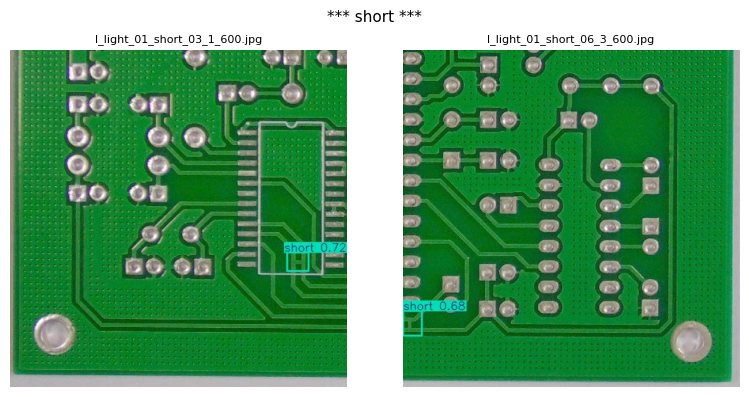

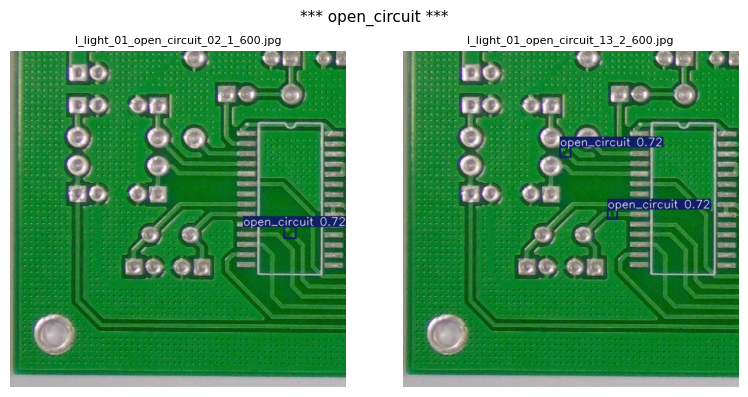

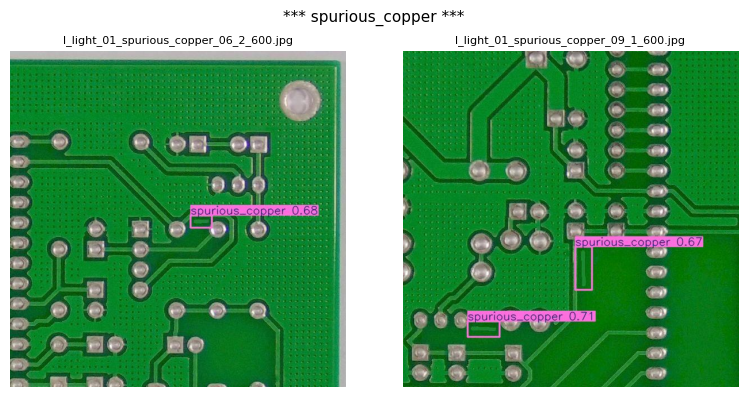

Images originales et prédictions sauvegardées dans app/sample_images/


In [29]:
# -----------------------------
# Inference on selected test images
# -----------------------------


from src.inference import load_yolo_model, save_annotated_prediction


# Load final model
final_model = load_yolo_model(best_models_dir / "best_yolo_tuned.pt")

test_images_dir = dataset_root / "test" / "images"
test_labels_dir = dataset_root / "test" / "labels"

# Output directories for Streamlit demo
app_originals_dir = project_root / "app" / "sample_images" / "originals"
app_predictions_dir = project_root / "app" / "sample_images" / "predictions"

app_originals_dir.mkdir(parents=True, exist_ok=True)
app_predictions_dir.mkdir(parents=True, exist_ok=True)


# Select max 2 images per class from ground-truth labels
images_per_class = defaultdict(list)

for label_path in sorted(test_labels_dir.glob("*.txt")):
    sample_id = "_".join(label_path.stem.split("_")[:-1])
    image_path = next(test_images_dir.glob(f"{sample_id}_*.jpg"), None)

    if image_path is None:
        continue

    with open(label_path, "r", encoding="utf-8") as file:
        class_ids = {int(line.split()[0]) for line in file if line.strip()}

    for class_id in class_ids:
        class_name = class_mapping[class_id]

        if len(images_per_class[class_name]) < 2:
            images_per_class[class_name].append(image_path)


# Generate and save demo images
for gt_class in class_names:
    image_paths = images_per_class[gt_class]

    if not image_paths:
        continue

    fig, axes = plt.subplots(1, len(image_paths), figsize=(8, 4))

    if len(image_paths) == 1:
        axes = [axes]

    fig.suptitle(f"*** {gt_class} ***", fontsize=11)

    for idx, (ax, image_path) in enumerate(zip(axes, image_paths), start=1):
        demo_name = f"{gt_class}_{idx:02d}"

        original_output_path = app_originals_dir / f"{demo_name}.jpg"
        prediction_output_path = app_predictions_dir / f"{demo_name}_pred.jpg"

        # Save original image for Streamlit input / API fallback
        shutil.copy2(image_path, original_output_path)

        # Run inference through src.inference and save annotated prediction
        save_annotated_prediction(
            model=final_model,
            image_path=image_path,
            output_path=prediction_output_path,
            confidence_threshold=config["inference"]["thresholds"]["confidence"],
            iou_threshold=config["inference"]["thresholds"]["iou"],
            image_size=config["inference"]["image_size"],
            device=resolve_device(config["inference"]["device"]),
        )

        ax.imshow(plt.imread(prediction_output_path))
        ax.set_title(image_path.name, fontsize=8)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

print("Images originales et prédictions sauvegardées dans app/sample_images/")


In [30]:
# -----------------------------
# Copy latest metrics to Streamlit assets
# -----------------------------

app_assets_dir = project_root / "app" / "assets"
app_assets_dir.mkdir(parents=True, exist_ok=True)

assets_to_copy = {
    metrics_dir / "benchmark_results.csv": app_assets_dir / "benchmark_results.csv",
    metrics_dir / "yolo_tuning_results.csv": app_assets_dir / "yolo_tuning_results.csv",
    metrics_dir / "per_class_metrics.csv": app_assets_dir / "per_class_metrics.csv",
    validation_dir / "validation" / "confusion_matrix_normalized.png": app_assets_dir / "confusion_matrix_normalized.png",
    best_run_results_path: app_assets_dir / "results.csv",
}

for source_path, target_path in assets_to_copy.items():
    if source_path.exists():
        shutil.copy2(source_path, target_path)
    else:
        print(f"Fichier manquant : {source_path}")

print("Assets Streamlit mis à jour.")

Assets Streamlit mis à jour.


In [31]:
# Vérification de l'arborescence :

def print_tree(root: Path, max_depth: int = 3, prefix: str = "") -> None:
    """Affiche une arborescence simple jusqu'à une profondeur donnée."""
    if max_depth < 0 or not root.exists():
        return

    print(f"{prefix}{root.name}/")
    if max_depth == 0:
        return

    children = sorted(root.iterdir(), key=lambda p: (p.is_file(), p.name.lower()))
    for child in children:
        if child.is_dir():
            print_tree(child, max_depth=max_depth - 1, prefix=prefix + "    ")
        else:
            print(f"{prefix}    {child.name}")

# Dossiers à vérifier
paths_to_check = [
    project_root,
    outputs_dir,
    best_models_dir,
    app_assets_dir,
]

for path in paths_to_check:
    print("\n" + "=" * 80)
    print(f"STRUCTURE: {path}")
    print("=" * 80)
    print_tree(path, max_depth=3)


STRUCTURE: ..
../
    .ipynb_checkpoints/
        config-checkpoint.yml
        environment-checkpoint.yml
    .pytest_cache/
        v/
            cache/
        .gitignore
        CACHEDIR.TAG
        README.md
    .ruff_cache/
        0.15.14/
            10777063613199574359
            11497533543479873055
            12485979529489207560
            14235738445181668473
            14796879752451734458
            14951498268559694240
            15311011682196592545
            16761867329569694481
            17167518559294417559
            17860895357861911313
            1924649058703836515
            7050854203792881960
            8381865043821222569
            8526358142050131682
        .gitignore
        CACHEDIR.TAG
    api/
        __pycache__/
            main.cpython-311.pyc
            schemas.cpython-311.pyc
        Dockerfile
        main.py
        requirements.txt
        schemas.py
    app/
        .ipynb_checkpoints/
            streamlit_app-checkpoint.p